In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [2]:
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

df_cycles   = pd.read_sql("SELECT * FROM fact_cycle_day", engine)
df_checkins = pd.read_sql("SELECT * FROM fact_daily_checkin", engine)

print(f"Cycle days: {len(df_cycles)} rows")
print(f"Check-ins:  {len(df_checkins)} rows")
df_cycles.head()

Cycle days: 1095 rows
Check-ins:  1095 rows


,date,cycle_day,phase,period_active,cycle_number,cycle_length
0,2023-06-01,1,menstrual,True,1,40
1,2023-06-02,2,menstrual,True,1,40
2,2023-06-03,3,menstrual,True,1,40
3,2023-06-04,4,menstrual,True,1,40
4,2023-06-05,5,menstrual,True,1,40


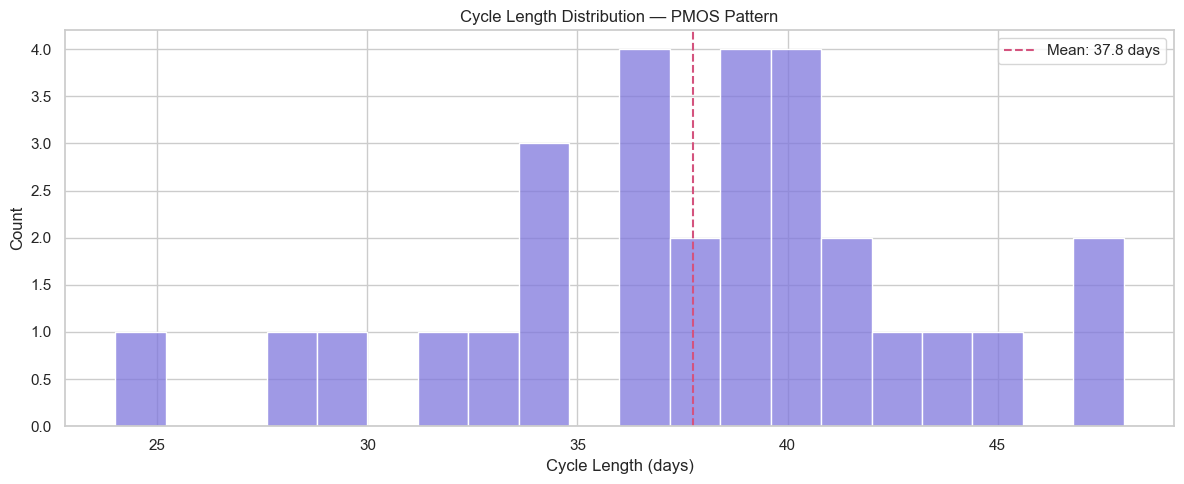

Average cycle length: 37.8 days
Shortest cycle: 24 days
Longest cycle:  48 days


In [3]:
cycle_lengths = df_cycles.groupby("cycle_number")["cycle_day"].max()

plt.figure()
sns.histplot(cycle_lengths, bins=20, color="#7F77DD")
plt.axvline(cycle_lengths.mean(), color="#D4537E", linestyle="--", label=f"Mean: {cycle_lengths.mean():.1f} days")
plt.title("Cycle Length Distribution — PMOS Pattern")
plt.xlabel("Cycle Length (days)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average cycle length: {cycle_lengths.mean():.1f} days")
print(f"Shortest cycle: {cycle_lengths.min()} days")
print(f"Longest cycle:  {cycle_lengths.max()} days")

C:\Users\HP\AppData\Local\Temp\ipykernel_34084\1579357449.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x="phase", y="energy_score",


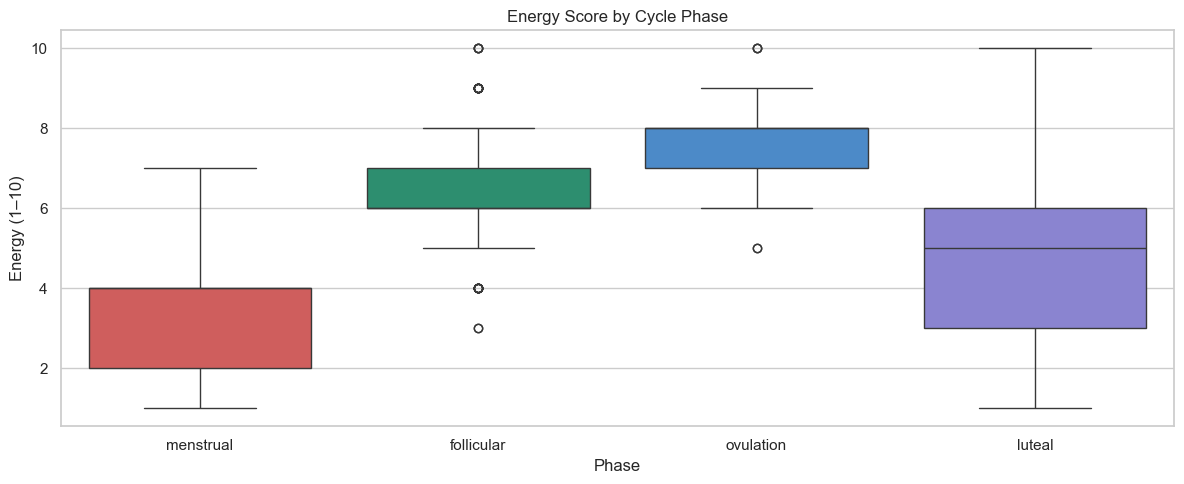

In [4]:
merged = df_checkins.merge(df_cycles[["date","phase"]], on="date")

phase_order = ["menstrual", "follicular", "ovulation", "luteal"]
colors      = ["#E24B4A", "#1D9E75", "#378ADD", "#7F77DD"]

plt.figure()
sns.boxplot(data=merged, x="phase", y="energy_score",
            order=phase_order, palette=colors)
plt.title("Energy Score by Cycle Phase")
plt.xlabel("Phase")
plt.ylabel("Energy (1–10)")
plt.tight_layout()
plt.show()

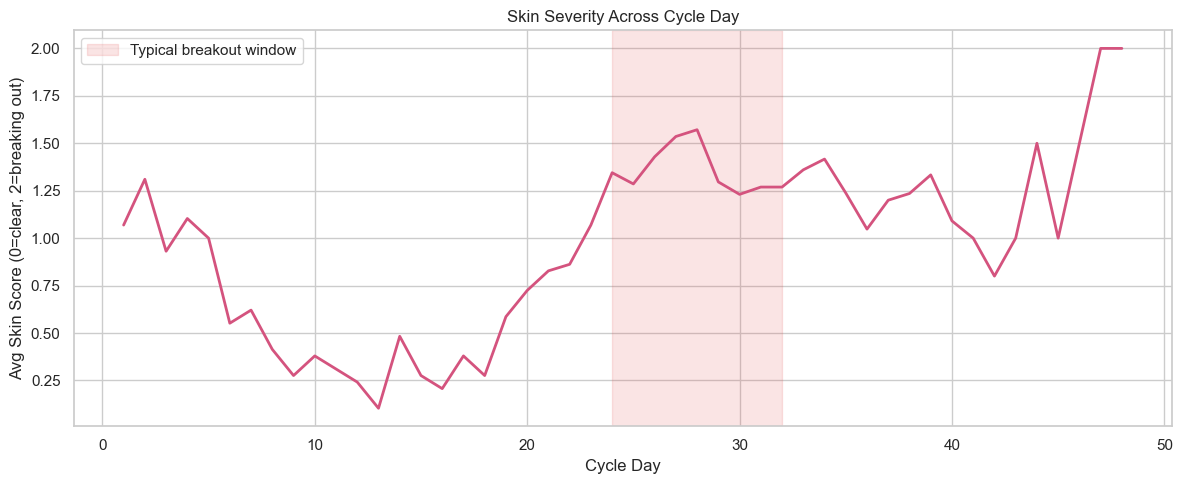

In [5]:
skin_map  = {"clear": 0, "okay": 1, "breaking_out": 2}
merged["skin_num"] = merged["skin_status"].map(skin_map)

avg_skin = merged.groupby("cycle_day")["skin_num"].mean().reset_index()

plt.figure()
plt.plot(avg_skin["cycle_day"], avg_skin["skin_num"], color="#D4537E", linewidth=2)
plt.axvspan(24, 32, alpha=0.15, color="#E24B4A", label="Typical breakout window")
plt.title("Skin Severity Across Cycle Day")
plt.xlabel("Cycle Day")
plt.ylabel("Avg Skin Score (0=clear, 2=breaking out)")
plt.legend()
plt.tight_layout()
plt.show()

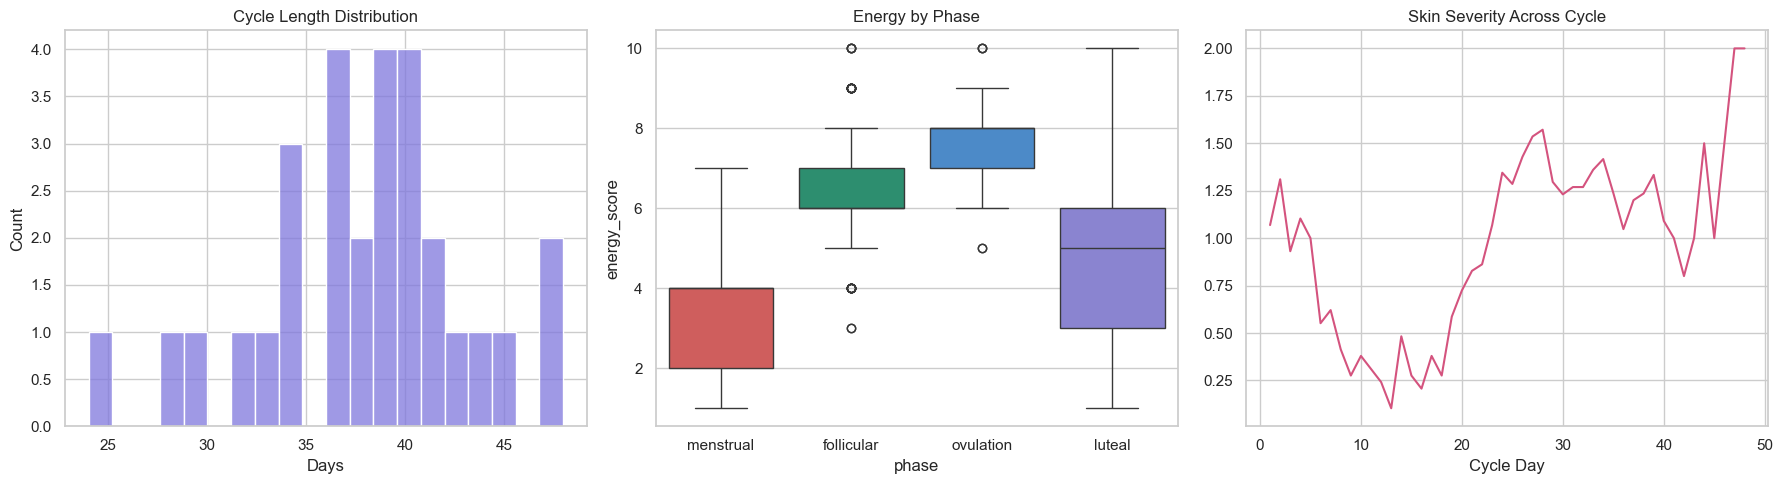

Chart saved to docs/


In [6]:
# Cell 6 — Save charts to docs folder
import os
os.makedirs("../docs", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1
cycle_lengths = df_cycles.groupby("cycle_number")["cycle_day"].max()
sns.histplot(cycle_lengths, bins=20, color="#7F77DD", ax=axes[0])
axes[0].set_title("Cycle Length Distribution")
axes[0].set_xlabel("Days")

# Chart 2
sns.boxplot(data=merged, x="phase", y="energy_score",
            order=phase_order, palette=colors, ax=axes[1], hue="phase", legend=False)
axes[1].set_title("Energy by Phase")

# Chart 3
axes[2].plot(avg_skin["cycle_day"], avg_skin["skin_num"], color="#D4537E")
axes[2].set_title("Skin Severity Across Cycle")
axes[2].set_xlabel("Cycle Day")

plt.tight_layout()
plt.savefig("../docs/eda_cycle_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to docs/")